Este código foi criado para desenvolver um modelo de CNN para quantificar células marcadas com fluorescencia, indicando presença da proteína na célula.

In [ ]:
pip install util-gfsilveira

# Imports data structuring

In [ ]:
#organização dos arquivos
import os
#salvar/carregar arquivos em diferentes formatos
import joblib
#organizando os arquivos de forma aleatória
import random
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#gerar imagem
import matplotlib.image as mpimg

# CNN template import

In [ ]:
#modelo de revisão redes neurais - cnn
from keras.models import Sequential
from keras.utils import to_categorical # Import directly from keras.utils
from util import meus_uteis, timeProcess, mask_corr_graphic, printLis
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

Documents from different files will be stored in this directory

In [ ]:
diretorio = '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC' #alimentando a variável com os arquivos da pasta datasets
lista_dados = os.listdir(diretorio) #listando os arquivos dessa pasta
printLis(lista_dados) #printando as diferentes listas

-------------
-=< Lista >=-
-------------
0 -> lista_imagem_100_resized_regre_HBMEC_fluo_2025-6-10.gz
1 -> lista_imagem_angulacoes_HBMEC_fluo_2025-6-10.gz
2 -> realçadas
3 -> lista_imagem_100_resized_regre_HBMEC_fluo_MFI_2025-11-13.gz
4 -> lista_imagem_angulacoes_HBMEC_fluo_MFI_2025-11-13.gz
5 -> lista_rotulos_angulacoes_HBMEC_fluo_MFI_2025-11-13.gz
6 -> lista_rotulo_100_resized_regre_HBMEC_fluo_MFI_2025-11-13.gz
7 -> rótulos_HBMEC_validação_10%_fluore_2025-11-13.gz
8 -> imagens_HBMEC_validação_10%_fluore_2025-11-13.gz
9 -> rotulos_treino_fluore_HBMEC_100_75_50_25_2025-11-17.gz
10 -> rótulos_HBMEC_validação_10%_fluore_2025-11-17.gz
11 -> imagens_treino_fluore_HBMEC_100_75_50_25_2025-11-17.gz
12 -> imagens_HBMEC_validação_10%_fluore_2025-11-17.gz
13 -> imagens_HBMEC_validação_10%_fluore_2025-11-18.gz
14 -> rótulos_HBMEC_validação_10%_fluore_2025-11-18.gz
15 -> imagens_treino_fluore_HBMEC_100_75_50_25_2025-11-18.gz
16 -> rotulos_treino_fluore_HBMEC_100_75_50_25_2025-11-18

Lists of all images in each file

In [ ]:
#lstando arquivos com as imagens 100%, 75%, 50%, 25%
for k, v in enumerate(lista_dados):
    if k in [3,4]:
        print(f'{k} -> {v}')

3 -> lista_imagem_100_resized_regre_HBMEC_fluo_MFI_2025-11-13.gz
4 -> lista_imagem_angulacoes_HBMEC_fluo_MFI_2025-11-13.gz


## x = features/images

In [ ]:
#0 - 100% somando todas as imagens de diferentes tamanho
X_cem = joblib.load(diretorio+ '/' + lista_dados[3])

# 2 - 75%
X_setcin = joblib.load(diretorio+ '/' + lista_dados[4])

# # 4 - 50%
# X_cinq = joblib.load(diretorio+ '/' + lista_dados[4])

# # 6 - 25%
# X_vincin = joblib.load(diretorio+ '/' + lista_dados[6])

x = np.asarray(list(X_cem) + list(X_setcin))

x.shape

(248, 300, 300, 3)

# y = labels

Opening the labels that were saved in the preparation of the images

In [ ]:
for k, v in enumerate(lista_dados):
    if k in [5,6]:
        print(f'{k} -> {v}')

5 -> lista_rotulos_angulacoes_HBMEC_fluo_MFI_2025-11-13.gz
6 -> lista_rotulo_100_resized_regre_HBMEC_fluo_MFI_2025-11-13.gz


In [ ]:
#1 - 100% somando todos os rótulos de diferentes tamanho
y_cem = joblib.load(diretorio+ '/' + lista_dados[5])

#3 - 75%
y_setcin = joblib.load(diretorio+ '/' + lista_dados[6])

# #4 - 50%
# y_cinq = joblib.load(diretorio+ '/' + lista_dados[5])

# #7 - 25%
# y_vincin = joblib.load(diretorio+ '/' + lista_dados[7])

y = np.asarray(list(y_cem) + list(y_setcin))

y.shape

(248,)

#Separando dados de validação

In [ ]:
#Train and test split datasets for CNN model
#função que separa as imagens em teste e treino
from sklearn.model_selection import train_test_split

10% dos 640 - foram separados para validação do modelo.

In [ ]:
zeros = list(np.zeros(224))
ones = list(np.ones(24))
lista = np.array(zeros + ones)
#lista

In [ ]:
random.shuffle(lista)
lista_valida = [True if i == 1 else False for i in lista]
lista_treino_test = [False if i == 1 else True for i in lista]
#np.array(lista_valida)

In [ ]:
#imagens
x_valida = x[lista_valida]
x_treino_test = x[lista_treino_test]

print(x_valida.shape)
print(x_treino_test.shape)

(24, 300, 300, 3)
(224, 300, 300, 3)


In [ ]:
#rótulos
y_valida = y[lista_valida]
y_treino_test = y[lista_treino_test]

print(y_valida.shape)
print(y_treino_test.shape)

(24,)
(224,)


In [ ]:
data = timeProcess()[1]
#Salvando 10$ das imagens para validação
joblib.dump(x_valida, '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/imagens_HBMEC_validação_10%_fluore_'+data+'.gz')
joblib.dump(y_valida, '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/rótulos_HBMEC_validação_10%_fluore_'+data+'.gz')

['/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/rótulos_HBMEC_validação_10%_fluore_2025-11-19.gz']

Test and training separation from a library.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_treino_test, y_treino_test, test_size=0.3, random_state=0)
#variáveis recebem o número de imagens para tes e treino
print(f'{X_train.shape} \n{X_test.shape} \n{y_train.shape} \n{y_test.shape}')

(156, 300, 300, 3) 
(68, 300, 300, 3) 
(156,) 
(68,)


In [ ]:
y_train = y_train.astype(float)
y_test = y_test.astype(float)
# print(int_array)
# print(int_array.dtype)


In [ ]:
#salvando os resultados de treino e teste
# joblib.dump(X_train, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/1_images_de_X_train_fluor_melhor_modelo_200_epochs_90%_'+data+'.gz')
# joblib.dump(y_train, '/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/2_rotulos_de_y_train_fluor_melhor_modelo_200_epochs_90%_'+data+'.gz')
joblib.dump(X_test, '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/imagens_treino_fluore_HBMEC_100_75_50_25_'+data+'.gz')
joblib.dump(y_test, '/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/rotulos_treino_fluore_HBMEC_100_75_50_25_'+data+'.gz')

['/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos HBMEC/rotulos_treino_fluore_HBMEC_100_75_50_25_2025-11-19.gz']

### Model determination

In [ ]:
# modelo = Sequential()
# modelo.add(Conv2D(32, kernel_size=3, activation='relu', input_shape=X_train[0].shape))
# #função de ativação relu é muito utilizado para problemas de regressão
# modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
# modelo.add(Conv2D(64, kernel_size=3, activation='relu'))
# modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
# modelo.add(Conv2D(128, kernel_size=3, activation='relu'))
# modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
# modelo.add(Conv2D(256, kernel_size=3, activation='relu'))
# modelo.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
# modelo.add(Flatten())
# modelo.add(Dropout(0.9))
# modelo.add(Dense(1, activation='linear'))
# #apenas uma saída e de forma linear
# modelo.compile(optimizer='adam', loss='mse', metrics=['mean_squared_error'])
# print(modelo.summary())

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

modelo = Sequential()

# Bloco 1
modelo.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=X_train[0].shape))
modelo.add(BatchNormalization())
modelo.add(MaxPooling2D(pool_size=(2,2)))

# Bloco 2
modelo.add(Conv2D(64, (3,3), activation='relu', padding='same'))
modelo.add(BatchNormalization())
modelo.add(MaxPooling2D(pool_size=(2,2)))

# Bloco 3
modelo.add(Conv2D(128, (3,3), activation='relu', padding='same'))
modelo.add(BatchNormalization())
modelo.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
modelo.add(Flatten())

# Camadas densas
modelo.add(Dense(128, activation='relu'))
modelo.add(Dropout(0.3))

modelo.add(Dense(64, activation='relu'))
modelo.add(Dropout(0.2))

# Saída de regressão
modelo.add(Dense(1, activation='linear'))

modelo.compile(optimizer='adam', loss='mse', metrics=['mean_squared_error'])
modelo.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 300, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,532,289 (85.95 MB)

 Trainable params: 22,531,841 (85.95 MB)

 Non-trainable params: 448 (1.75 KB)

# Training and testing epochs

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
# # simple early stopping
# es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=18)

In [ ]:
# # fit model
# history = modelo.fit(X_train,y_train,
#                     validation_data=(X_test, y_test),
#                     epochs=200, verbose=2,
#                     callbacks=[es]
#                      )

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

history = modelo.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[es, lr],
    verbose=2
)

Epoch 1/200
5/5 - 28s - 6s/step - loss: 4051.9795 - mean_squared_error: 4051.9795 - val_loss: 907.0758 - val_mean_squared_error: 907.0758 - learning_rate: 1.0000e-03
Epoch 2/200
5/5 - 1s - 143ms/step - loss: 1027.9963 - mean_squared_error: 1027.9963 - val_loss: 900.7775 - val_mean_squared_error: 900.7775 - learning_rate: 1.0000e-03
Epoch 3/200
5/5 - 1s - 121ms/step - loss: 745.1403 - mean_squared_error: 745.1403 - val_loss: 947.4170 - val_mean_squared_error: 947.4170 - learning_rate: 1.0000e-03
Epoch 4/200
5/5 - 1s - 121ms/step - loss: 451.3022 - mean_squared_error: 451.3022 - val_loss: 1084.5619 - val_mean_squared_error: 1084.5619 - learning_rate: 1.0000e-03
Epoch 5/200
5/5 - 1s - 141ms/step - loss: 218.0126 - mean_squared_error: 218.0126 - val_loss: 575.0872 - val_mean_squared_error: 575.0872 - learning_rate: 1.0000e-03
Epoch 6/200
5/5 - 1s - 146ms/step - loss: 169.9798 - mean_squared_error: 169.9798 - val_loss: 69.3324 - val_mean_squared_error: 69.3324 - learning_rate: 1.0000e-03
Ep

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Faça as predições
pred = modelo.predict(X_test)

# Converte para 1D caso necessário
y_true = y_test.ravel()
y_pred = pred.ravel()

# Métricas
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Exibição formatada
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step
R²: -27.7726
MAE: 0.3259
MSE: 0.2895
RMSE: 0.5380


In [ ]:
print(f"{r2 * 100:.2f}% R² Score")
print(f"{mae:.2f} MAE (Erro médio absoluto)")
print(f"{mse:.2f} MSE (Erro médio quadrático)")
print(f"{rmse:.2f} RMSE (Raiz do erro médio quadrático)")


-2777.26% R² Score
0.33 MAE (Erro médio absoluto)
0.29 MSE (Erro médio quadrático)
0.54 RMSE (Raiz do erro médio quadrático)


## Accuracy Assessment

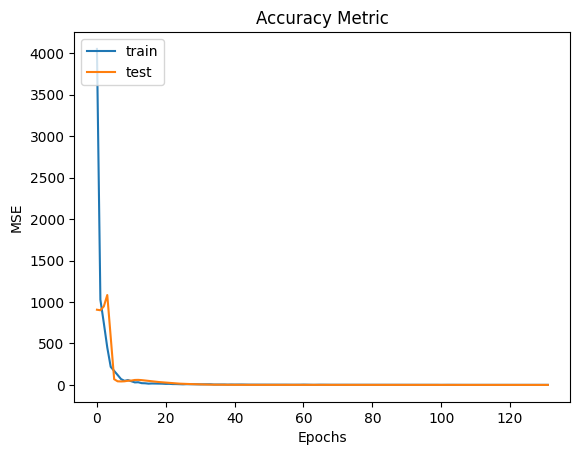

In [ ]:
#gráfico avaliando a acurácia a partir de treino e teste
plt.plot(history.history['mean_squared_error'])
plt.plot(history.history['val_mean_squared_error'])
plt.title('Accuracy Metric')
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


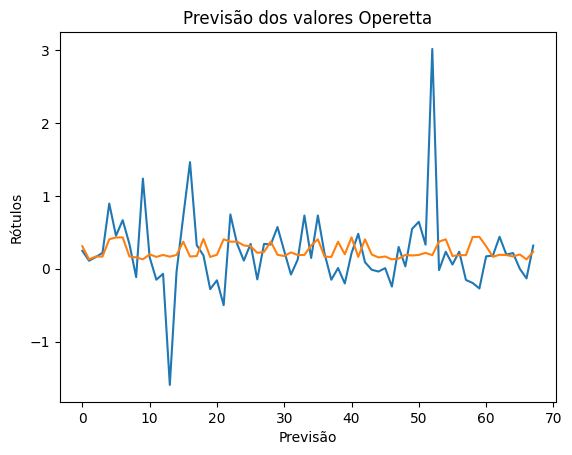

In [ ]:
#avaliando a previsão do modelo com os rótulos
prev = modelo.predict(X_test)
plt.title('Previsão dos valores Operetta')
plt.ylabel('Rótulos')
plt.xlabel('Previsão')
plt.plot(prev)#azul - o que o modelo previu
plt.plot(y_test)#laranja - o que se sabe - observado
plt.show()

In [ ]:
# Qualit model analisys
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error

In [ ]:
#buscando pelas métricas
print(f"{round(r2_score(y_test, prev) * 100, 2)}% r2_score") #raíz quadrada
print(f"{round(mean_absolute_error(y_test, prev), 2)} Erro médio absoluto")
print(f"{round(mean_squared_error(y_test, prev), 2)} Erro médio quadrático") #erro médio quadrático
# print(f"{round(median_absolute_error(y_test, prev), 2)}")#Erro médio absoluto sem %
#print(f"{round(median(y_test, prev), 2)} mediana") #erro médio quadrático

-2777.26% r2_score
0.33 Erro médio absoluto
0.29 Erro médio quadrático


In [ ]:
# Métricas do modelo de regressão
r2 = r2_score(y_test, prev)
mae = mean_absolute_error(y_test, prev)
mse = mean_squared_error(y_test, prev)
rmse = np.sqrt(mse)

print(f"{round(r2 * 100, 2)}% R² score")
print(f"{round(mae, 2)} Mean Absolute Error (MAE)")
print(f"{round(mse, 2)} Mean Squared Error (MSE)")
print(f"{round(rmse, 2)} Root Mean Squared Error (RMSE)")

-2777.26% R² score
0.33 Mean Absolute Error (MAE)
0.29 Mean Squared Error (MSE)
0.54 Root Mean Squared Error (RMSE)


In [ ]:
import numpy as np

def calculate_r_squared_manual(y_true, y_pred):
    """
    Calculates the coefficient of determination (R-squared) manually.

    Args:
        y_true (list or np.array): The true (observed) values.
        y_pred (list or np.array): The predicted values from the model.

    Returns:
        float: The R-squared value.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate the mean of the true values
    y_true_mean = np.mean(y_true)

    # Calculate the Sum of Squares of Residuals (SS_res)
    ss_res = np.sum((y_true - y_pred) ** 2)

    # Calculate the Total Sum of Squares (SS_tot)
    ss_tot = np.sum((y_true - y_true_mean) ** 2)

    # Handle the case where SS_tot is zero (e.g., all y_true values are the same)
    if ss_tot == 0:
        return 1.0  # R-squared is 1 if there's no variance in y_true

    # Calculate R-squared
    r_squared = 1 - (ss_res / ss_tot)

    return r_squared

# === YOUR MODEL'S VALUES ===
# y_test = seus valores reais
# prev   = previsões geradas pelo modelo (modelo.predict)

r_squared_value = calculate_r_squared_manual(y_test, prev)
print(f"Manual R²: {r_squared_value}")


The manually calculated R-squared is: 0.9264705882352942


In [ ]:
import numpy as np
print("Variância:", np.var(y_test))
print("Desvio Padrão:", np.std(y_test))
print("Amplitude:", np.ptp(y_test))


Variância: 0.010060417894121754
Desvio Padrão: 0.10030163455358918
Amplitude: 0.308794


In [ ]:
modelo.save('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/teste modelos/modelo_fluore_HBMEC_100_75_50_25_'+data+'.keras')